<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20Force006.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
grid_size = 512
e_folds = 10000
beta_tensor = 1/16  # Hypothetical graviton coupling


In [2]:
def generate_tensor_field(grid_size, phase_shift=0):
    x = np.linspace(0, 4*np.pi, grid_size)
    y = np.linspace(0, 4*np.pi, grid_size)
    X, Y = np.meshgrid(x, y)
    return np.sin(X + phase_shift) * np.sin(Y + phase_shift)


In [3]:
def tensor_coupling(tensor_A, tensor_B, beta=1/16):
    grad_A_x, grad_A_y = np.gradient(tensor_A)
    grad_B_x, grad_B_y = np.gradient(tensor_B)

    theta_A = np.arctan2(grad_A_y, grad_A_x)
    theta_B = np.arctan2(grad_B_y, grad_B_x)
    phase_diff = theta_A - theta_B

    modulation = -beta * np.sin(phase_diff)
    tensor_A += modulation
    tensor_B -= modulation
    return tensor_A, tensor_B


In [4]:
def evolve_field(field, steps, decay=0.9999):
    evolved = field.copy()
    for _ in range(steps):
        evolved *= decay
        evolved += np.random.normal(0, 0.001, field.shape)
    return evolved


In [5]:
def memory_fidelity(original, evolved):
    return np.corrcoef(original.flatten(), evolved.flatten())[0,1]


Tensor A fidelity: 0.9418
Tensor B fidelity: 0.9418


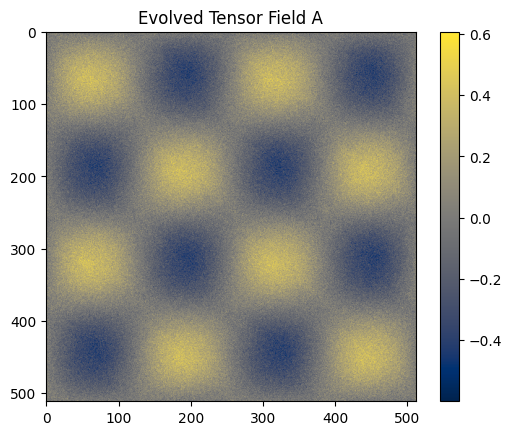

In [6]:
tensor_A = generate_tensor_field(grid_size)
tensor_B = generate_tensor_field(grid_size, phase_shift=np.pi/4)
tensor_A_c, tensor_B_c = tensor_coupling(tensor_A, tensor_B, beta_tensor)

tensor_A_e = evolve_field(tensor_A_c, e_folds)
tensor_B_e = evolve_field(tensor_B_c, e_folds)

f_A = memory_fidelity(tensor_A_c, tensor_A_e)
f_B = memory_fidelity(tensor_B_c, tensor_B_e)

print(f"Tensor A fidelity: {f_A:.4f}")
print(f"Tensor B fidelity: {f_B:.4f}")

plt.imshow(tensor_A_e, cmap='cividis')
plt.title("Evolved Tensor Field A")
plt.colorbar()
plt.show()
